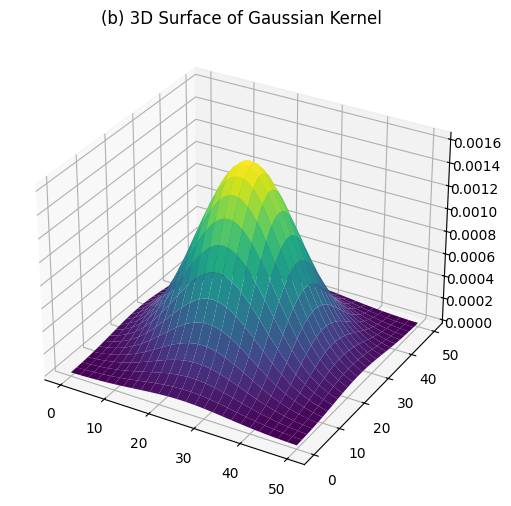

AttributeError: module 'matplotlib.pyplot' has no attribute 'figur'

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Get  Gaussian Kernel Manually 
def get_gaussian_kernel(size, sigma):
    center = size // 2
    kernel = np.zeros((size, size))
    for x in range(size):
        for y in range(size):
            # Calculate distance from center
            diff = np.sqrt((x - center)**2 + (y - center)**2)
            # Apply Gaussian Formula
            kernel[x, y] = np.exp(-(diff**2) / (2 * sigma**2))
    return kernel / np.sum(kernel) # Normalize

filename = 'runway.png'  
file_path = fr"d:\computer_Vision_Inclass_11_26\{filename}"

#  Load Image in Grayscale
img = cv.imread(file_path, cv.IMREAD_GRAYSCALE)

if img is None:
    print(" ERROR: Image not found.")
else:
    #  Compute 5x5 Kernel (sigma=2) 
    sigma =2 
    kernel_5x5 = get_gaussian_kernel(5, sigma)

    #  Visualize 51x51 Kernel as 3D Surface 
    kernel_51 = get_gaussian_kernel(51, 10) 
    
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    x = np.arange(0, 51, 1)
    y = np.arange(0, 51, 1)
    X, Y = np.meshgrid(x, y)
    
    # Plot Surface
    ax.plot_surface(X, Y, kernel_51, cmap='viridis', linewidth=0)
    ax.set_title('(b) 3D Surface of Gaussian Kernel')
    plt.show()

    
    # Apply the 5x5 kernel to the runway image
    img_manual = cv.filter2D(img, -1, kernel_5x5)

    # OpenCV Built-in Function 
    img_builtin = cv.GaussianBlur(img, (5, 5), 2)

    # Display Results
    plt.figur(figsize=(12, 5))

    # 1. Original
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Runway')
    plt.axis('off')

    # 2. Manual Result
    plt.subplot(1, 3, 2)
    plt.imshow(img_manual, cmap='gray')
    plt.title('(c) Manual Filter')
    plt.axis('off')

    # 3. Built-in Result
    plt.subplot(1, 3, 3)
    plt.imshow(img_builtin, cmap='gray')
    plt.title('(d) cv.GaussianBlur')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

  